# Result Visualization

In [1]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
FIGURES_DIR = PROJECT_ROOT / "results" / "figures"
TABLES_DIR = PROJECT_ROOT / "results" / "tables"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
TABLES_DIR.mkdir(parents=True, exist_ok=True)

# District names are in Korean, so register a CJK-capable font to avoid broken glyphs
KOREAN_FONT_PATH = "/usr/share/fonts/truetype/nanum/NanumSquareRoundR.ttf"
fm.fontManager.addfont(KOREAN_FONT_PATH)
plt.rcParams["font.family"] = fm.FontProperties(fname=KOREAN_FONT_PATH).get_name()
plt.rcParams["axes.unicode_minus"] = False

baseline_pcd = pd.read_csv(PROCESSED_DIR / "baseline_pcd_scores.csv")
fvi_fdi = pd.read_csv(PROCESSED_DIR / "fvi_fdi_scores.csv")
risk_classification = pd.read_csv(PROCESSED_DIR / "temporal_risk_classification.csv")
final_scores = pd.read_csv(PROCESSED_DIR / "final_district_risk_scores.csv")

print(baseline_pcd.shape, fvi_fdi.shape, risk_classification.shape, final_scores.shape)


(50, 7) (25, 5) (25, 8) (25, 6)


## Baseline PCD Matrix (2020 vs 2022)

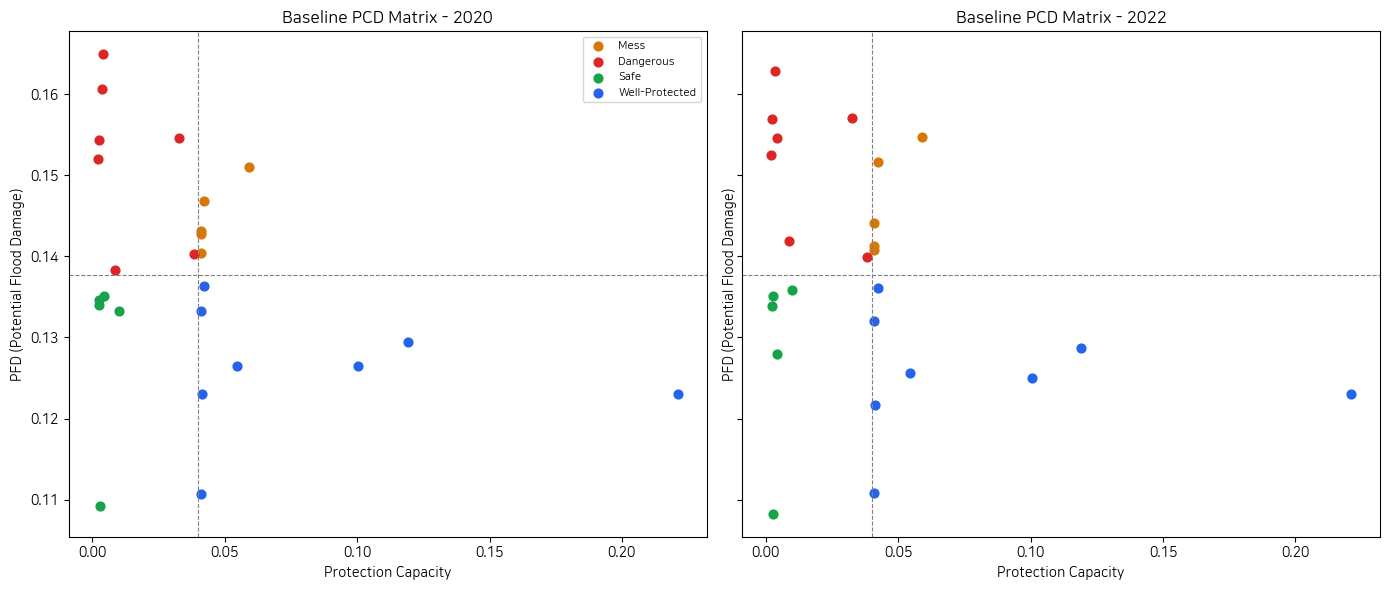

In [2]:
QUADRANT_COLORS = {
    "Mess": "#d97706", "Dangerous": "#dc2626", "Safe": "#16a34a", "Well-Protected": "#2563eb",
}

fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharex=True, sharey=True)
for ax, year in zip(axes, [2020, 2022]):
    subset = baseline_pcd[baseline_pcd["year"] == year]
    for quadrant, color in QUADRANT_COLORS.items():
        pts = subset[subset["quadrant"] == quadrant]
        ax.scatter(pts["protection_capacity"], pts["pfd"], color=color, label=quadrant, s=40)
    ax.axvline(subset["protection_capacity"].mean(), color="gray", linestyle="--", linewidth=0.8)
    ax.axhline(subset["pfd"].mean(), color="gray", linestyle="--", linewidth=0.8)
    ax.set_title(f"Baseline PCD Matrix - {year}")
    ax.set_xlabel("Protection Capacity")
    ax.set_ylabel("PFD (Potential Flood Damage)")
axes[0].legend(loc="upper right", fontsize=8)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "baseline_pcd_matrix_2020_2022.png", dpi=150)
plt.show()


## FVI-FDI Matrix (2020 vs 2022)

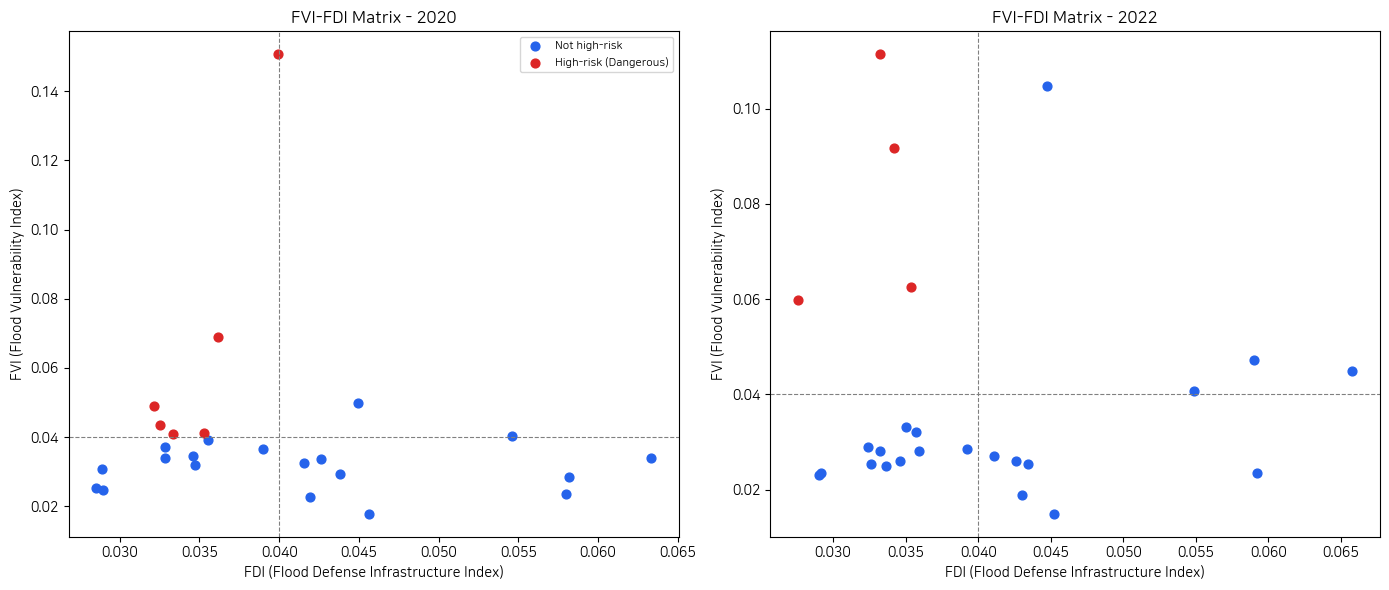

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
for ax, year in zip(axes, [2020, 2022]):
    fvi_col, fdi_col = f"fvi_{year}", f"fdi_{year}"
    x, y = fvi_fdi[fdi_col], fvi_fdi[fvi_col]
    high_risk = (y >= y.mean()) & (x < x.mean())
    ax.scatter(x[~high_risk], y[~high_risk], color="#2563eb", label="Not high-risk", s=40)
    ax.scatter(x[high_risk], y[high_risk], color="#dc2626", label="High-risk (Dangerous)", s=40)
    ax.axvline(x.mean(), color="gray", linestyle="--", linewidth=0.8)
    ax.axhline(y.mean(), color="gray", linestyle="--", linewidth=0.8)
    ax.set_title(f"FVI-FDI Matrix - {year}")
    ax.set_xlabel("FDI (Flood Defense Infrastructure Index)")
    ax.set_ylabel("FVI (Flood Vulnerability Index)")
axes[0].legend(loc="upper right", fontsize=8)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "fvi_fdi_matrix_2020_2022.png", dpi=150)
plt.show()


## Temporal Risk Transition Types (2020 -> 2022)

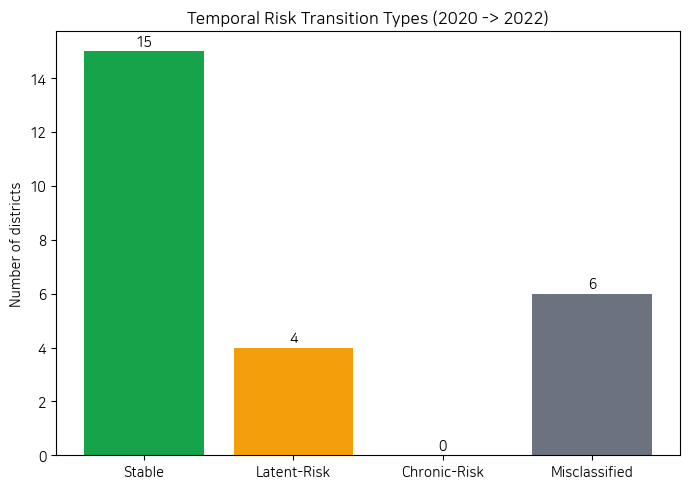

In [4]:
order = ["Stable", "Latent-Risk", "Chronic-Risk", "Misclassified"]
counts = risk_classification["risk_transition_type"].value_counts().reindex(order, fill_value=0)

fig, ax = plt.subplots(figsize=(7, 5))
colors = ["#16a34a", "#f59e0b", "#dc2626", "#6b7280"]
ax.bar(counts.index, counts.values, color=colors)
for i, v in enumerate(counts.values):
    ax.text(i, v + 0.2, str(v), ha="center")
ax.set_title("Temporal Risk Transition Types (2020 -> 2022)")
ax.set_ylabel("Number of districts")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "risk_transition_type_counts.png", dpi=150)
plt.show()

risk_classification.to_csv(TABLES_DIR / "temporal_risk_classification_table.csv", index=False, encoding="utf-8-sig")


## Final District Ranking (risk_coefficient)

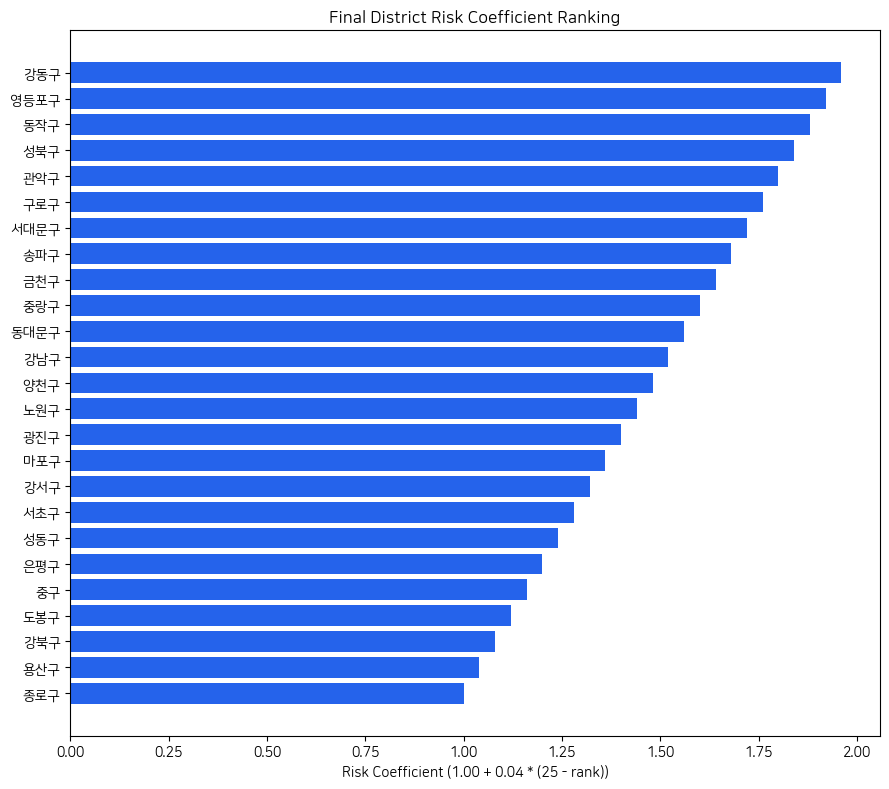

Saved figures to: /home/dslab/shlee/flood-risk-insurance-model/results/figures
Saved tables to: /home/dslab/shlee/flood-risk-insurance-model/results/tables


In [5]:
ranked = final_scores.sort_values("rank")

fig, ax = plt.subplots(figsize=(9, 8))
ax.barh(ranked["district"], ranked["risk_coefficient"], color="#2563eb")
ax.invert_yaxis()
ax.set_xlabel("Risk Coefficient (1.00 + 0.04 * (25 - rank))")
ax.set_title("Final District Risk Coefficient Ranking")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "final_risk_coefficient_ranking.png", dpi=150)
plt.show()

ranked.to_csv(TABLES_DIR / "final_district_ranking_table.csv", index=False, encoding="utf-8-sig")
print(f"Saved figures to: {FIGURES_DIR}")
print(f"Saved tables to: {TABLES_DIR}")
